## Import Libraries

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

## Device Configuration

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## REMOVE CORRUPTED IMAGES

In [3]:
bad_images = []

for folder in ['dataset/Cat', 'dataset/Dog']:

    for file in os.listdir(folder):

        file_path = os.path.join(folder, file)

        # remove non-jpg files
        if not file.lower().endswith('.jpg'):

            os.remove(file_path)

            print("Deleted:", file_path)

            continue

        # remove corrupted images
        try:

            img = Image.open(file_path)

            img.verify()

        except:

            bad_images.append(file_path)

            print("Bad image:", file_path)

C:\Users\Asus\AppData\Roaming\Python\Python313\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


## Delete Corrupted Images

In [4]:
for file in bad_images:

    os.remove(file)

    print("Removed corrupted file:", file)


print("Dataset cleanup completed")


Dataset cleanup completed


## Image Transformations

In [5]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

## Load Dataset

In [6]:
dataset = datasets.ImageFolder(
    root='dataset',
    transform=transform
)

print(dataset.classes)

['Cat', 'Dog']


## Train-Test Split

In [7]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

## DataLoader

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

## CNN Model

In [9]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,16,3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*14*14,512),
            nn.ReLU(),

            nn.Linear(512,1),
            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.conv(x)
        x = self.fc(x)

        return x

## Initialize Model

In [10]:
model = CNN().to(device)

print(model)

CNN(
  (conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12544, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=1, bias=True)
    (4): Sigmoid()
  )
)


## Loss and Optimizer

In [11]:
criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## Device Setup

In [12]:
device = torch.device(

    "cuda" if torch.cuda.is_available()

    else "cpu"
)

print(device)

cpu


## Training Loop

In [13]:
epochs = 10

train_losses = []

train_accuracies = []


for epoch in range(epochs):

    model.train()

    running_loss = 0

    correct = 0

    total = 0


    for images, labels in train_loader:


        # move data to gpu/cpu
        images = images.to(device)

        labels = labels.float().unsqueeze(1).to(device)


        # clear previous gradients
        optimizer.zero_grad()


        # forward pass
        outputs = model(images)


        # calculate loss
        loss = criterion(outputs, labels)


        # backpropagation
        loss.backward()


        # update weights
        optimizer.step()


        # total loss
        running_loss += loss.item()


        # prediction
        predicted = (outputs > 0.5).float()


        correct += (predicted == labels).sum().item()

        total += labels.size(0)


    # epoch metrics
    epoch_loss = running_loss / len(train_loader)

    epoch_acc = correct / total


    train_losses.append(epoch_loss)

    train_accuracies.append(epoch_acc)


    print(f"Epoch [{epoch+1}/{epochs}]")

    print(f"Loss: {epoch_loss:.4f}")

    print(f"Accuracy: {epoch_acc:.4f}")

Epoch [1/10]
Loss: 0.6549
Accuracy: 0.6025
Epoch [2/10]
Loss: 0.5839
Accuracy: 0.6917
Epoch [3/10]
Loss: 0.5284
Accuracy: 0.7346
Epoch [4/10]
Loss: 0.4809
Accuracy: 0.7667
Epoch [5/10]
Loss: 0.4521
Accuracy: 0.7861
Epoch [6/10]
Loss: 0.4250
Accuracy: 0.8023
Epoch [7/10]
Loss: 0.3937
Accuracy: 0.8213
Epoch [8/10]
Loss: 0.3670
Accuracy: 0.8371
Epoch [9/10]
Loss: 0.3381
Accuracy: 0.8501
Epoch [10/10]
Loss: 0.3197
Accuracy: 0.8594


## Save Model

In [16]:
torch.save(

    model.state_dict(),

    'model/model.pth'
)

## Accuracy Graph

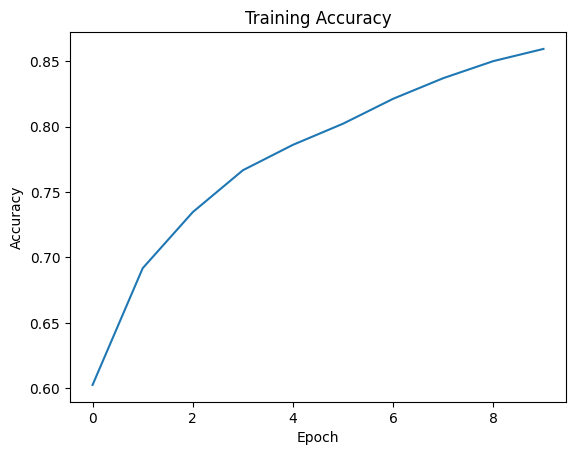

In [17]:
import matplotlib.pyplot as plt

plt.plot(train_accuracies)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

## Loss Graph

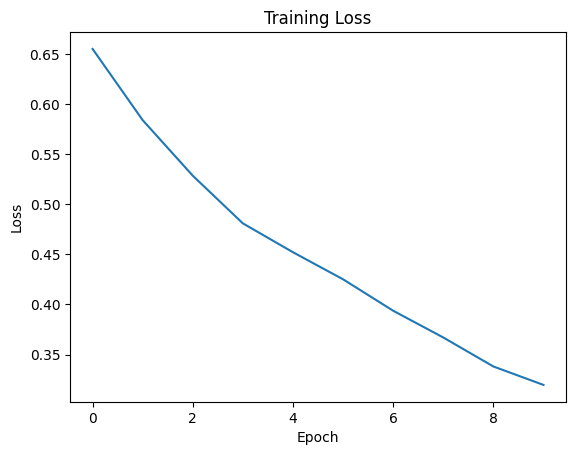

In [18]:
plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()